## Importing and Initial Variables

In [99]:
import pandas as pd
from utils import credentials as cd, config as config
from dateutil import parser as dateparser
import requests
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt

COLUMN_TEMPLATE = config.TODOIST_COLUMNS
FILENAME = "my-energysystem-tasks.csv"
COLUMNS_RENAMED = dict(zip(config.TODOIST_COLUMNS['keep'],config.TODOIST_COLUMNS['renamed']))
mostrecentdate = None
df = None
data_path = Path(Path.cwd(),r"data/",FILENAME)
baseurl = "https://api.todoist.com/api/v1/"
get_tasks = "tasks/completed/by_completion_date/"
get_projects = "projects/"
date_format = r"%Y/%m/%d"
headers = {"Authorization": f"Bearer {cd.api_key}"}

request_body = {
    "since" : None,
    "until" : None,
    "limit": "200"
}

In [100]:
len(config.TODOIST_COLUMNS['keep']) == len(config.TODOIST_COLUMNS['renamed'])

True

In [101]:
Path.exists(data_path)

True

## Functions

In [102]:
def isoToString(date, format):
    input_date = dateparser.parse(date)
    return input_date.strftime(format=format)

def column_is_type(df):
    return df.transform(lambda x: x.apply(type)).drop_duplicates().iloc[0]

def split_column(data,split,key):
    test = data[[key,split]]
    test = test[test.iloc[:, 1].notna()]
    # print(column_is_type(test.iloc[:,1]))
    if column_is_type(test.iloc[:,1]) is dict:
        unnest = test[split].apply(pd.Series)
        source_names = unnest.columns.tolist()
        updated_names = [split.capitalize() + part.capitalize() for part in source_names]

        rename_zip = zip(source_names, updated_names)
        rename_dict = dict(rename_zip)

        renamed = unnest.rename(rename_dict, axis=1)
        output = test.join(renamed)
        return output

def todistRequest(request, param, header):
    items = []
    result_type = "items"
    cursor = None
    if 'project' in request:
            result_type = "results"
    url = baseurl + request
    while True:
        params = param
        if cursor:
            params["cursor"] = cursor

        response = requests.get(url, params=params, headers=header)
        response.raise_for_status()
        data = response.json()

        items.extend(data.get(result_type))

        cursor = data.get("next_cursor")
        if not cursor:
            break
    return items

## Check for existing archive of tasks

In [103]:
# Path.read_bytes(data_path)
if Path.exists(data_path) is False:
    print("file not found.\npull from earliest month start.")
else:
    print("file found. Opening to collect last task date")
    df = pd.read_csv(data_path).infer_objects()
    mostrecentdate = df['CompletedDate'].max()
    

file found. Opening to collect last task date


In [104]:
# df.columns.to_list()

In [105]:
COLUMN_TEMPLATE['renamed']

['CreatedDate',
 'SubtaskOrder',
 'CompletedDate',
 'TaskContent',
 'TaskDetails',
 'TaskDuration',
 'TaskID',
 'TaskLabels',
 'NoteCount',
 'ParentTaskID',
 'ProjectID',
 'TaskPriority',
 'UpdatedDate',
 'DueDate',
 'IsRecurringTask']

### Grab the last completed date as a starting point to pull more tasks

In [106]:
end_date = datetime.now()

if mostrecentdate is None:
    print("No most recent date found")
    start_date = datetime.now()
    start_date = datetime.replace(start_date,day=1)
else:    
    mostrecentdate = dateparser.parse(mostrecentdate)
    start_date = mostrecentdate
    
iso_start_date = start_date.isoformat()
iso_end_date = end_date.isoformat()
    # datetime.strptime("5/1/2026","%m/%d/%Y")
# end_date = datetime.strptime("5/18/2026","%m/%d/%Y")



## Collect Project and Tasks

In [107]:
request_body['since'] = start_date
request_body['until'] = end_date

In [108]:
project_request = request_body

projects = todistRequest(get_projects, project_request, headers)
proj_df = pd.DataFrame(projects)
proj_df = proj_df[['id','name']]
proj_df.rename(columns={"name":"ProjectName","id":"ProjectID"},inplace=True)
proj_df

,ProjectID,ProjectName
0,6Mw9JcR2gjPR3Xjm,Inbox
1,6XQ4r58cjq52mMvR,THIS WEEK
2,6XQ4rFJqXG3g4VH9,NEXT WEEK
3,6XQ4rFr9QRhXRMj7,THIS MONTH
4,6XQ4rGM3VhmcrvWQ,NEXT MONTH
5,6XQ4rH982p3r3H2g,LONG-TERM | ON HOLD
6,6gRgWCHV3JgFVpxH,PLANNING
7,6gRgWG8Hh74482vX,ROUTINES
8,6gqvrcXmxvQ3vh2w,Household Chores


In [109]:
items = todistRequest(get_tasks,request_body,headers)

## Build Task Table

In [110]:
task_table = pd.DataFrame(items)

# if df is not None:
#     task_table = pd.concat([task_table,df])

task_table = task_table.reset_index(drop=True)
# task_table


In [111]:
id_column = (task_table.columns.get_loc("id"), "id")

## Split due date iterable into unique columns

In [112]:
date_columns = split_column(data=task_table,split='due',key=id_column[1])

if date_columns is not None:
    date_columns['DueDate'] = date_columns['DueDate'].apply(dateparser.parse)
    date_columns['DueDate'] = [date.strftime(date_format) for date in date_columns['DueDate']]
    combined_df = pd.merge(left=task_table, right=date_columns, on=id_column[1],how='left')
# combined_df

In [113]:
dates_to_convert = ['added_at', 'completed_at','updated_at']

combined_df[dates_to_convert] = combined_df[dates_to_convert].apply(lambda row: [isoToString(rowItem,date_format) for rowItem in row])

In [114]:
full_data = pd.merge(left=combined_df, right=proj_df,how='left',left_on="project_id",right_on='ProjectID')
# full_data
# proj_df

In [115]:
full_data.columns

Index(['added_at', 'added_by_uid', 'assigned_by_uid', 'checked', 'child_order',
       'completed_at', 'completed_by_uid', 'completed_count', 'content',
       'day_order', 'deadline', 'description', 'due_x', 'duration', 'goal_ids',
       'id', 'is_collapsed', 'is_deleted', 'labels', 'note_count', 'parent_id',
       'postponed_count', 'priority', 'project_id', 'responsible_uid',
       'section_id', 'updated_at', 'user_id', 'due_y', 'DueDate',
       'DueIs_recurring', 'DueLang', 'DueString', 'DueTimezone', 'ProjectID',
       'ProjectName'],
      dtype='str')

In [116]:
# for column in COLUMN_TEMPLATE['renamed']:
#     if column not in final_df:
#         print(f"column not found: {column}")

## Drop Raw data & Unneeded columns

In [117]:
final_df = full_data.drop(columns=COLUMN_TEMPLATE['drop'], errors="ignore")

final_df = final_df.rename(columns=COLUMNS_RENAMED)

final_df['IsRecurringTask'] = final_df['IsRecurringTask'].fillna(value=False)
final_df['DueDate'] = final_df['DueDate'].fillna("1900/01/01")
final_df['TaskDuration'] = final_df['TaskDuration'].fillna(0)
final_df['ParentTaskID'] = final_df['ParentTaskID'].fillna(value="")
final_df = final_df[list(COLUMNS_RENAMED.values())]
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CreatedDate      2 non-null      str   
 1   SubtaskOrder     2 non-null      int64 
 2   CompletedDate    2 non-null      str   
 3   TaskContent      2 non-null      str   
 4   TaskDetails      2 non-null      str   
 5   TaskDuration     2 non-null      object
 6   TaskID           2 non-null      str   
 7   TaskLabels       2 non-null      object
 8   NoteCount        2 non-null      int64 
 9   ParentTaskID     2 non-null      object
 10  ProjectID        2 non-null      str   
 11  TaskPriority     2 non-null      int64 
 12  UpdatedDate      2 non-null      str   
 13  DueDate          2 non-null      str   
 14  IsRecurringTask  2 non-null      bool  
dtypes: bool(1), int64(3), object(3), str(8)
memory usage: 358.0+ bytes


In [118]:
if df is None:
    final_df.to_csv(data_path,index=False)
else:
    for i, row in final_df.iterrows():
        if row['TaskID'] not in df['TaskID'].values:
            print(f"Task {row['TaskID']} not in existing tasks")
            row_to_append = row.to_frame().T
            row_to_append.to_csv(data_path,mode='a',index=False,header=False)
            refreshed_df = pd.concat([df,row.to_frame().T], ignore_index=True)
        else:
            refreshed_df = df

# Make some graphs

In [119]:
char_to_replace = {
    "[": "",
    "]": "",
    "'": "", 
    #", ": ""
}
refreshed_df['TaskLabels'] = refreshed_df['TaskLabels'].str.replace(char_to_replace)
refreshed_df['TaskLabels']

0                            energy_medium, recharging
1                             depleting, energy_medium
2      delayed gratification, depleting, energy_medium
3                 energy_low, recharging, relationship
4                            energy_medium, recharging
                            ...                       
213                               energy_medium, quick
214                              career, energy_medium
215                 energy_low, fun, quick, recharging
216                               energy_medium, quick
217                               energy_medium, quick
Name: TaskLabels, Length: 218, dtype: str

In [120]:
exploding = refreshed_df['TaskLabels'].str.split(",")
exploded = exploding.explode()

In [121]:
exploded = exploded.str.strip()

In [122]:
tag_counts = exploded.value_counts().reset_index(name='count')
tag_counts.columns = ['Tag', 'Count']
tag_counts['Tag'] = tag_counts['Tag'].replace("","no label")

In [123]:
unique_tags = tag_counts['Tag'].drop_duplicates()
unique_tags = unique_tags.str.strip()
unique_tags.sort_values()



11                   career
3     delayed gratification
1                 depleting
6               energy_high
2                energy_low
0             energy_medium
10                      fun
12                 no label
4                     quick
5                recharging
7              relationship
8                    social
9                    zombie
13                 ✅_streak
Name: Tag, dtype: str

In [124]:
tag_counts = tag_counts[tag_counts['Tag'] != '✅_streak']

In [125]:
tag_counts = tag_counts.sort_values('Count').reset_index(drop=True)

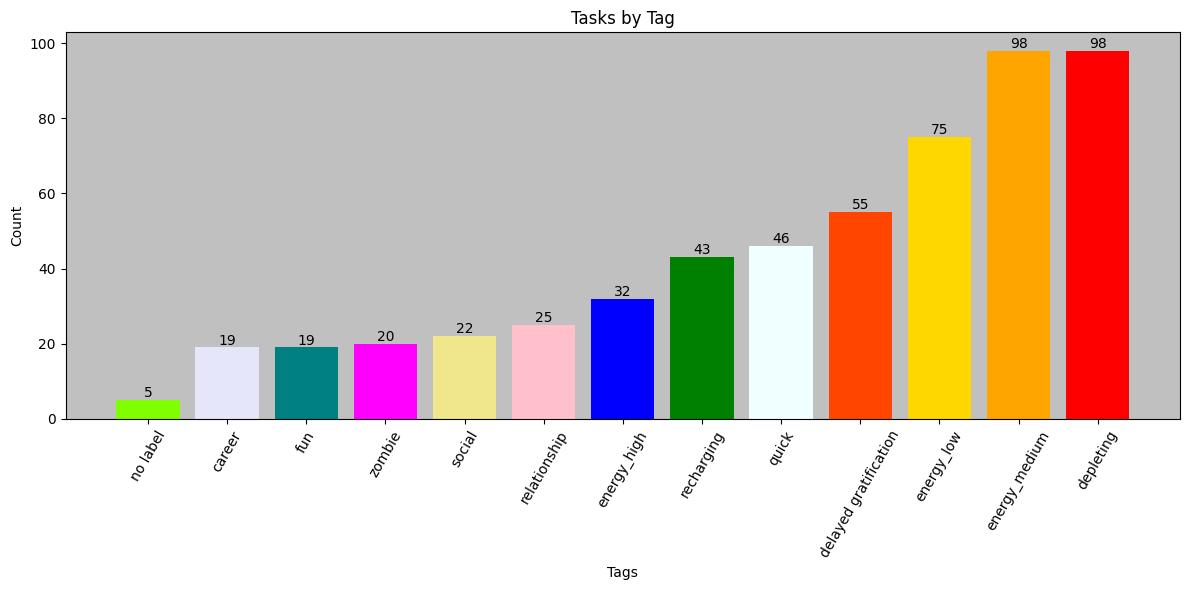

In [126]:
tag_color_map = {
    'delayed gratification': 'orangered',  # Dark Orange
    'depleting': 'Red',  # Red
    'career': 'lavender',  # Purple
    'energy_low': 'Gold',  # Gold
    'energy_medium': "Orange",  # Orange
    'energy_high': 'Blue',  # Blue
    'fun': 'Teal',  # Teal
    'quick': 'azure',  # Dark Green
    'recharging': 'Green',  # Green
    'relationship': 'pink',  # Navy
    'social': 'khaki',  # Cyan
    'zombie': 'Magenta',  # Magenta,
    'no label': 'chartreuse'
}

def add_labels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i] + 0.75, y[i], ha="center")  # Placing text slightly above the bar

tag_counts['color'] = tag_counts['Tag'].map(tag_color_map)


# # Optional: Generate more colors dynamically
plt.figure(figsize=(12,6))
bars = plt.bar(tag_counts['Tag'], tag_counts['Count'], color = tag_counts['color'])

add_labels(tag_counts['Tag'], tag_counts['Count'])

plt.xlabel('Tags')
plt.ylabel('Count')
plt.title('Tasks by Tag')

plt.xticks(rotation=60)
plt.tight_layout()

ax = plt.gca()
ax.set_facecolor("silver")
plt.show()

In [127]:
tag_counts["% total"] = round((tag_counts['Count'] / tag_counts['Count'].sum()) * 100, 2)

In [128]:
tag_counts

,Tag,Count,color,% total
0,no label,5,chartreuse,0.90
1,career,19,lavender,3.41
2,fun,19,Teal,3.41
3,zombie,20,Magenta,3.59
4,social,22,khaki,3.95
5,relationship,25,pink,4.49
6,energy_high,32,Blue,5.75
7,recharging,43,Green,7.72
8,quick,46,azure,8.26
9,delayed gratification,55,orangered,9.87


# Visuals

Each Visual listed below should have a chart for this week, this month, and all time
1. Pie chart comparing depleting tasks vs recharging tasks
2. Pie Chart comparing labels on tasks while omitting depleting and recharging
3. Bar chart comparing energy_high, energy_medium, and energy_low completed tasks. Group by depleting and recharging 

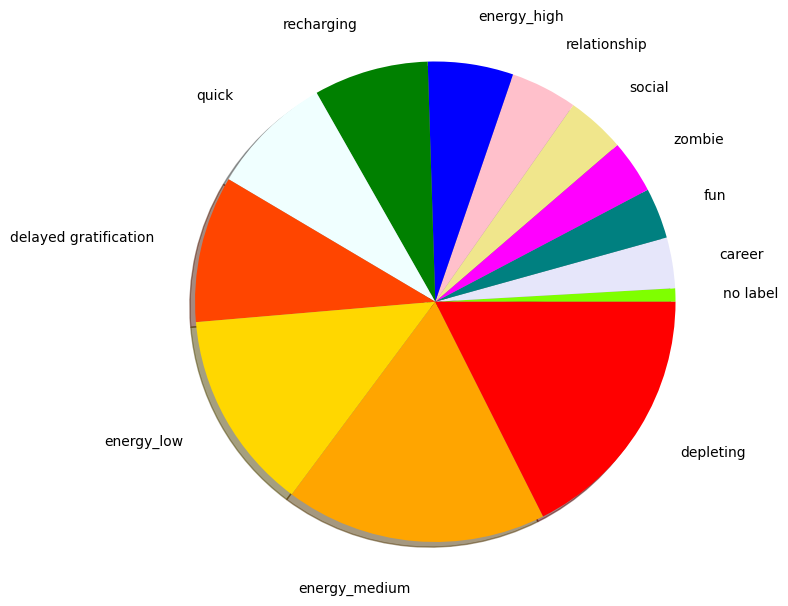

In [139]:
plt.figure(figsize=(12,6))
pie = plt.pie(
        x= tag_counts['% total'],
        shadow=True,
        labeldistance=1.2,
        radius=1.3,
        labels=tag_counts['Tag'],
        colors=tag_counts['color'])

In [130]:
tag_counts[['Tag','% total']]

,Tag,% total
0,no label,0.90
1,career,3.41
2,fun,3.41
3,zombie,3.59
4,social,3.95
5,relationship,4.49
6,energy_high,5.75
7,recharging,7.72
8,quick,8.26
9,delayed gratification,9.87
